## Story 1: Data Cleaning

#### 1. Dataset Format Inspection

Before loading the dataset, it is important to inspect the raw file structure. Large datasets may use different delimiters such as commas, tabs, or semicolons. Identifying the correct delimiter ensures that the dataset is parsed correctly and prevents issues such as all data being loaded into a single column.

In [2]:
# Inspect the first few lines of the raw file

with open("../Data/openfoodfacts.csv", "r", encoding="utf-8", errors="ignore") as file:
    for i in range(5):
        print(file.readline())

code	url	creator	created_t	created_datetime	last_modified_t	last_modified_datetime	last_modified_by	last_updated_t	last_updated_datetime	product_name	abbreviated_product_name	generic_name	quantity	packaging	packaging_tags	packaging_en	packaging_text	brands	brands_tags	brands_en	categories	categories_tags	categories_en	origins	origins_tags	origins_en	manufacturing_places	manufacturing_places_tags	labels	labels_tags	labels_en	emb_codes	emb_codes_tags	first_packaging_code_geo	cities	cities_tags	purchase_places	stores	countries	countries_tags	countries_en	ingredients_text	ingredients_tags	ingredients_analysis_tags	allergens	allergens_en	traces	traces_tags	traces_en	serving_size	serving_quantity	no_nutrition_data	additives_n	additives	additives_tags	additives_en	nutriscore_score	nutriscore_grade	nova_group	pnns_groups_1	pnns_groups_2	food_groups	food_groups_tags	food_groups_en	states	states_tags	states_en	brand_owner	environmental_score_score	environmental_score_grade	nutrient_levels_tags	p

#### 2. Loading the Dataset

The Open Food Facts dataset uses tab-separated values (TSV) rather than standard comma-separated values (CSV). Therefore, the dataset is loaded using a tab delimiter to ensure that all columns are parsed correctly. To improve performance and memory efficiency, only a subset of rows is loaded during the initial analysis phase.

In [ ]:
import pandas as pd

# Load a manageable subset of the dataset
raw_food_df  = pd.read_csv(
    "../Data/openfoodfacts.csv",
    sep="\t",
    nrows=200000,    low_memory=False
)

print("Dataset Shape:", raw_food_df.shape)

Dataset Shape: (200000, 211)


#### 3. Initial Dataset Inspection

After loading the dataset, the next step is to inspect its dimensions and available columns. This helps identify the variables relevant to the market gap analysis and guides subsequent data cleaning and feature engineering steps.

In [4]:
# Display basic dataset information

print("\nNumber of rows and columns:")
print(raw_food_df.shape)

print("\nFirst 20 columns:")
print(raw_food_df.columns[:20])

print("\nTotal columns:")
print(len(raw_food_df.columns))


Number of rows and columns:
(200000, 211)

First 20 columns:
Index(['code', 'url', 'creator', 'created_t', 'created_datetime',
       'last_modified_t', 'last_modified_datetime', 'last_modified_by',
       'last_updated_t', 'last_updated_datetime', 'product_name',
       'abbreviated_product_name', 'generic_name', 'quantity', 'packaging',
       'packaging_tags', 'packaging_en', 'packaging_text', 'brands',
       'brands_tags'],
      dtype='object')

Total columns:
211


#### 4. Verifying Required Features

The market gap analysis focuses on product categories, nutritional content, and ingredients. Before proceeding with data cleaning, it is necessary to verify that all required variables are present in the dataset.

In [5]:
required_columns = [
    "product_name",
    "categories_tags",
    "sugars_100g",
    "proteins_100g",
    "fiber_100g",
    "ingredients_text"
]

for col in required_columns:
    if col in raw_food_df.columns:
        print(f"✓ {col}")
    else:
        print(f"✗ {col}")

✓ product_name
✓ categories_tags
✓ sugars_100g
✓ proteins_100g
✓ fiber_100g
✓ ingredients_text


#### 5. Assessing Data Quality

Before cleaning the dataset, it is important to identify missing values in the key variables used for the analysis. Products without names, categories, sugar values, or protein values cannot contribute meaningfully to the market gap analysis and may need to be removed.

In [6]:
key_columns = [
    "product_name",
    "categories_tags",
    "sugars_100g",
    "proteins_100g"
]

raw_food_df[key_columns].isnull().sum()

product_name         8779
categories_tags     92438
sugars_100g        164201
proteins_100g      162781
dtype: int64

#### Insights from the results

Out of 200,000 rows, that means:  

* About 82% are missing sugar values.  
* About 81% are missing protein values.  
* About 46% are missing category information.  

#### 6. Evaluating Data Completeness

While individual columns contain a large number of missing values, it is important to determine how many products contain all the information required for analysis. This helps quantify the usable portion of the dataset before applying cleaning rules.

In [7]:
# Count rows that have complete information
required_columns = [
    "product_name",
    "categories_tags",
    "sugars_100g",
    "proteins_100g"
]

complete_records = raw_food_df.dropna(subset=required_columns)

print("Rows before cleaning:", len(raw_food_df))
print("Rows with complete information:", len(complete_records))
print(
    "Percentage retained:",
    round(len(complete_records) / len(raw_food_df) * 100, 2),
    "%"
)

Rows before cleaning: 200000
Rows with complete information: 18170
Percentage retained: 9.09 %


#### 7. Evaluating Cleaning Strategy

Before removing records with missing values, it is important to assess how each field impacts the available sample size. Since the analysis primarily depends on product names, categories, sugar values, and protein values, products missing any of these fields will be excluded from the final analytical dataset.

In [8]:
required_columns = [
    "product_name",
    "categories_tags",
    "sugars_100g",
    "proteins_100g"
]

clean_food_df = raw_food_df.dropna(
    subset=required_columns
).copy()

print("Rows after removing missing values:", len(clean_food_df))

Rows after removing missing values: 18170


#### 8. Exploring Product Categories

The next step is to examine the category information available in the cleaned dataset. Understanding the most common categories will help design a logical category grouping strategy and support the identification of market opportunities within the snack segment.

In [9]:
# Display a sample of category tags

clean_food_df["categories_tags"].dropna().head(20)

689                             en:asian-style-ready-meal
840     en:beverages-and-beverages-preparations,en:bev...
865     en:plant-based-foods-and-beverages,en:plant-ba...
875     en:snacks,en:sweet-snacks,en:biscuits-and-cake...
890     en:breakfasts,en:spreads,en:sweet-spreads,fr:p...
892     en:plant-based-foods-and-beverages,en:plant-ba...
946     en:meats-and-their-products,en:meats,en:prepar...
947     en:meats-and-their-products,en:meats,en:prepar...
954     en:seafood,en:fishes-and-their-products,en:fis...
955     en:beverages,en:carbonated-drinks,en:sodas,en:...
959     en:meats-and-their-products,en:meats,en:prepar...
968     en:meats-and-their-products,en:meats,en:prepar...
1002    en:plant-based-foods-and-beverages,en:plant-ba...
1005    en:dietary-supplements,en:bodybuilding-supplem...
1019    en:dairies,en:fermented-foods,en:fermented-mil...
1080    en:plant-based-foods-and-beverages,en:beverage...
1113    en:plant-based-foods-and-beverages,en:plant-ba...
1142    en:sna

#### 9. Identifying Common Category Keywords

The Open Food Facts dataset stores category information as comma-separated tags. Reviewing the most common tags provides insight into how products are classified and informs the creation of high-level business categories.

In [10]:
from collections import Counter

category_counter = Counter()

for categories in clean_food_df["categories_tags"].dropna():
    tags = str(categories).split(",")
    category_counter.update(tags)

category_counter.most_common(30)

[('en:plant-based-foods-and-beverages', 7456),
 ('en:plant-based-foods', 6950),
 ('en:cereals-and-potatoes', 4388),
 ('en:snacks', 3613),
 ('en:sweet-snacks', 2382),
 ('en:cereals-and-their-products', 2193),
 ('en:dairies', 2114),
 ('en:breads', 1987),
 ('en:fermented-foods', 1900),
 ('en:fermented-milk-products', 1889),
 ('en:desserts', 1779),
 ('en:breakfasts', 1518),
 ('en:dairy-desserts', 1518),
 ('en:fermented-dairy-desserts', 1479),
 ('en:yogurts', 1451),
 ('en:breakfast-cereals', 1317),
 ('en:fruits-and-vegetables-based-foods', 1113),
 ('en:beverages', 1052),
 ('en:condiments', 1016),
 ('en:meals', 1011),
 ('en:biscuits-and-cakes', 1008),
 ('en:undefined', 968),
 ('en:meats-and-their-products', 886),
 ('en:salty-snacks', 853),
 ('en:confectioneries', 842),
 ('en:sauces', 818),
 ('en:appetizers', 758),
 ('en:frozen-foods', 606),
 ('en:biscuits', 592),
 ('en:cocoa-and-its-products', 589)]

#### 10. Removing Nutritional Outliers

Nutritional values are reported per 100 grams of product. Therefore, values below 0 grams or above 100 grams are biologically impossible and likely represent data entry errors. These records are removed to improve the reliability of the analysis.

In [11]:
analysis_df = clean_food_df[
    (clean_food_df["sugars_100g"] >= 0) &
    (clean_food_df["sugars_100g"] <= 100) &
    (clean_food_df["proteins_100g"] >= 0) &
    (clean_food_df["proteins_100g"] <= 100)
].copy()

print("Rows after outlier removal:", len(analysis_df))

Rows after outlier removal: 18119


### Data Cleaning Summary

The cleaning process involved removing products with missing values in critical analytical fields, including product name, category information, sugar content, and protein content. Additionally, biologically impossible nutritional values (less than 0g or greater than 100g per 100g) were filtered out.

Starting from a subset of 200,000 products, the final analytical dataset contained 18,119 products suitable for market gap analysis.

## Story 2: Category Wrangler

#### 1. Creating High-Level Product Categories

The Open Food Facts dataset contains thousands of detailed category tags, making analysis difficult at a business level. To improve interpretability, products are grouped into a smaller number of high-level categories based on commonly occurring keywords within the category tags.

This approach allows products with similar characteristics to be analyzed together and supports the identification of market opportunities within major snack-related segments.

In [12]:
def assign_primary_category(category_tags):

    if pd.isna(category_tags):
        return "Other"

    category_tags = str(category_tags).lower()

    # Protein & Fitness
    if any(keyword in category_tags for keyword in [
        "protein", "bodybuilding", "sports-nutrition"
    ]):
        return "Protein & Fitness"

    # Breakfast & Cereals
    elif any(keyword in category_tags for keyword in [
        "breakfast", "cereal"
    ]):
        return "Breakfast & Cereals"

    # Biscuits & Bakery
    elif any(keyword in category_tags for keyword in [
        "biscuit", "cake", "bread", "bakery"
    ]):
        return "Biscuits & Bakery"

    # Chocolate & Confectionery
    elif any(keyword in category_tags for keyword in [
        "chocolate", "cocoa", "confection"
    ]):
        return "Chocolate & Confectionery"

    # Dairy
    elif any(keyword in category_tags for keyword in [
        "dairy", "yogurt", "milk", "cheese"
    ]):
        return "Dairy Products"

    # Snacks
    elif any(keyword in category_tags for keyword in [
        "snack", "salty-snack"
    ]):
        return "Snacks"

    # Beverages
    elif any(keyword in category_tags for keyword in [
        "beverage", "drink", "juice", "soda"
    ]):
        return "Beverages"

    # Plant-Based Foods
    elif any(keyword in category_tags for keyword in [
        "plant-based", "vegetable", "fruit"
    ]):
        return "Plant-Based Foods"

    # Meals & Prepared Foods
    elif any(keyword in category_tags for keyword in [
        "meal", "prepared"
    ]):
        return "Meals & Prepared Foods"

    # Meat & Seafood
    elif any(keyword in category_tags for keyword in [
        "meat", "fish", "seafood", "poultry"
    ]):
        return "Meat & Seafood"

    else:
        return "Other"

#### 2. Applying Category Mapping

The category assignment function is applied to each product to generate a single high-level category. This simplifies the dataset and enables category-level comparisons in later stages of the analysis.

In [13]:
analysis_df["primary_category"] = (
    analysis_df["categories_tags"]
    .apply(assign_primary_category)
)

analysis_df["primary_category"].value_counts()

primary_category
Breakfast & Cereals          4746
Beverages                    3000
Other                        2775
Dairy Products               2306
Biscuits & Bakery            1252
Meals & Prepared Foods       1075
Chocolate & Confectionery    1060
Snacks                        995
Meat & Seafood                620
Protein & Fitness             235
Plant-Based Foods              55
Name: count, dtype: int64

## Story 3: Nutrient Matrix Preparation

#### 1. Nutritional Profile Overview

To identify potential market opportunities, the distribution of sugar and protein content is examined. Summary statistics provide insight into typical nutritional values and help define thresholds for identifying high-protein and low-sugar products.

In [14]:
analysis_df[["sugars_100g", "proteins_100g"]].describe()

,sugars_100g,proteins_100g
count,18119.000000,18119.000000
mean,12.650703,8.736624
std,17.106736,10.392639
min,0.000000,0.000000
25%,1.500000,2.900000
50%,5.260000,6.896552
75%,16.251581,10.597872
max,100.000000,100.000000


#### 2. Identifying the High Protein, Low Sugar Opportunity Zone

To identify underserved market opportunities, products are classified based on their nutritional profile. Products containing at least 10g of protein per 100g and no more than 5g of sugar per 100g are considered part of the target "Healthy Snacking" zone.

This segment represents products that align with consumer demand for high-protein, low-sugar alternatives.

In [15]:
# Define the opportunity zone

opportunity_df = analysis_df[
    (analysis_df["proteins_100g"] >= 10) &
    (analysis_df["sugars_100g"] <= 5)
].copy()

print("Products in High Protein + Low Sugar zone:", len(opportunity_df))

Products in High Protein + Low Sugar zone: 3429


In [16]:
opportunity_df["primary_category"].value_counts()

primary_category
Breakfast & Cereals          711
Meat & Seafood               502
Other                        489
Meals & Prepared Foods       454
Dairy Products               441
Beverages                    347
Biscuits & Bakery            205
Protein & Fitness            126
Snacks                       125
Chocolate & Confectionery     23
Plant-Based Foods              6
Name: count, dtype: int64

#### 3. Opportunity Penetration by Category

Absolute product counts alone do not reveal market opportunities. To understand how well each category serves health-conscious consumers, the proportion of products that fall within the High Protein and Low Sugar segment is calculated for each category.

In [17]:
# Total products per category
total_category_counts = analysis_df["primary_category"].value_counts()

# Opportunity products per category
opportunity_category_counts = opportunity_df["primary_category"].value_counts()

# Calculate percentage
opportunity_summary = pd.DataFrame({
    "total_products": total_category_counts,
    "high_protein_low_sugar_products": opportunity_category_counts
}).fillna(0)

opportunity_summary["opportunity_percentage"] = (
    opportunity_summary["high_protein_low_sugar_products"]
    / opportunity_summary["total_products"]
    * 100
).round(2)

opportunity_summary.sort_values(
    by="opportunity_percentage",
    ascending=False
)

,total_products,high_protein_low_sugar_products,opportunity_percentage
primary_category,,,
Meat & Seafood,620,502,80.97
Protein & Fitness,235,126,53.62
Meals & Prepared Foods,1075,454,42.23
Dairy Products,2306,441,19.12
Other,2775,489,17.62
Biscuits & Bakery,1252,205,16.37
Breakfast & Cereals,4746,711,14.98
Snacks,995,125,12.56
Beverages,3000,347,11.57


In [18]:
opportunity_df[["proteins_100g", "sugars_100g"]].mean()

proteins_100g    20.256058
sugars_100g       1.615273
dtype: float64

## Story 4: The Recommendation  

Insight: The biggest market opportunity      

Based on the data, the biggest market opportunity is in the Chocolate & Confectionery category, specifically targeting products with approximately 20g of protein per 100g and less than 2g of sugar per 100g.

## Candidate's Choice Feature : The Market Gap

A Market Gap Score was developed to quantify category-level opportunities. The score combines category size with the proportion of products meeting healthy nutritional criteria.

This metric helps distinguish between categories that are already saturated with healthy offerings and categories where consumer demand may be underserved. By ranking categories according to this score, decision-makers can prioritize product development investments more effectively.

In [19]:
opportunity_summary["market_gap_score"] = (
    opportunity_summary["total_products"] *
    (100 - opportunity_summary["opportunity_percentage"])
)

opportunity_summary.sort_values(
    by="market_gap_score",
    ascending=False
)

,total_products,high_protein_low_sugar_products,opportunity_percentage,market_gap_score
primary_category,,,,
Breakfast & Cereals,4746,711,14.98,403504.92
Beverages,3000,347,11.57,265290.00
Other,2775,489,17.62,228604.50
Dairy Products,2306,441,19.12,186509.28
Biscuits & Bakery,1252,205,16.37,104704.76
Chocolate & Confectionery,1060,23,2.17,103699.80
Snacks,995,125,12.56,87002.80
Meals & Prepared Foods,1075,454,42.23,62102.75
Meat & Seafood,620,502,80.97,11798.60


## Strategic Interpretation

Two opportunity perspectives emerged from the analysis.

The Market Gap Score identified Breakfast & Cereals as the largest category-level opportunity due to its substantial market size and relatively low proportion of High Protein and Low Sugar products.

However, because the client's objective is to launch a Healthy Snacking line, Chocolate & Confectionery represents the most strategically attractive target category. Only 2.17% of products in this category meet healthy nutritional criteria, indicating a significant gap between consumer health trends and existing product offerings.

## Bonus User Story: The "Hidden Gem" (Protein Source Frequency )

The frequency of protein-source ingredients provides insight into the raw materials most commonly used in successful high-protein and low-sugar products.

In [20]:
opportunity_df["ingredients_text"].notna().sum()

np.int64(2567)

### Exploring Ingredient Information

Before identifying common protein sources, a sample of ingredient lists is reviewed to understand the structure and terminology used across products.

In [21]:
opportunity_df["ingredients_text"].dropna().sample(10, random_state=42)

93781     WHEAT FLOUR, NIACIN, FERROUS SULFATE (IRON), T...
163739                          Turkey, natural flavorings.
160177                           Sardines, olive oil, salt.
92999     nonfat cheddar cheese (pasteurized skim milk, ...
193541    Semolina (wheat), durum flour (wheat), niacin,...
132353                        cashews, sea salt, peanut oil
166728    Cultured grade a non fat _milk_, chicory root ...
26141     Wheat Flour (Wheat Flour, Calcium Carbonate, I...
116972    pork***, sea salt, dextrose, contains less tha...
174169    Blanc de poulet d'origine britannique rôti (14...
Name: ingredients_text, dtype: object

### Identifying Common Protein Sources

To understand which ingredients contribute most frequently to high-protein and low-sugar products, ingredient lists were searched for common protein-source keywords. These sources were grouped into broader categories such as dairy proteins, meat proteins, seafood proteins, soy proteins, and nut-based proteins.

In [22]:
# Combine all ingredient text into one large string

ingredients_text = " ".join(
    opportunity_df["ingredients_text"]
    .dropna()
    .astype(str)
    .str.lower()
)

protein_sources = {
    "Milk / Dairy": [
        "milk", "cheese", "whey", "casein", "yogurt"
    ],
    "Meat / Poultry": [
        "chicken", "turkey", "pork", "beef", "poulet"
    ],
    "Seafood": [
        "fish", "sardine", "tuna", "salmon"
    ],
    "Soy": [
        "soy", "soja"
    ],
    "Nuts": [
        "peanut", "cashew", "almond"
    ]
}

source_counts = {}

for source, keywords in protein_sources.items():
    count = sum(
        ingredients_text.count(keyword)
        for keyword in keywords
    )
    source_counts[source] = count

source_counts

{'Milk / Dairy': 2923,
 'Meat / Poultry': 1076,
 'Seafood': 152,
 'Soy': 938,
 'Nuts': 177}

In [23]:
protein_source_df = (
    pd.DataFrame(
        source_counts.items(),
        columns=["Protein Source", "Frequency"]
    )
    .sort_values(
        by="Frequency",
        ascending=False
    )
)

protein_source_df

,Protein Source,Frequency
0,Milk / Dairy,2923
1,Meat / Poultry,1076
3,Soy,938
4,Nuts,177
2,Seafood,152


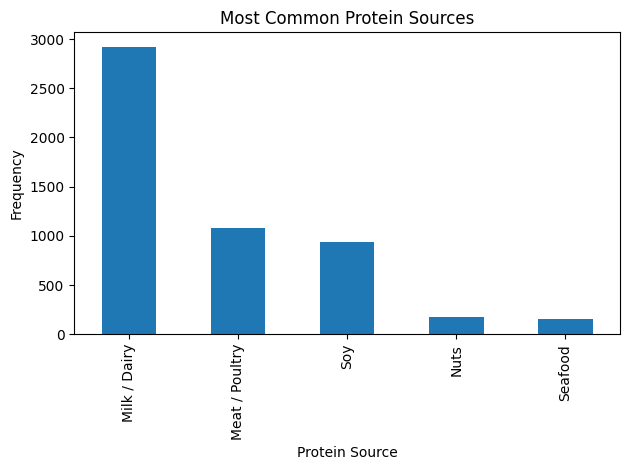

In [24]:
import matplotlib.pyplot as plt

protein_source_df.plot(
    kind="bar",
    x="Protein Source",
    y="Frequency",
    legend=False
)

plt.title("Most Common Protein Sources")
plt.ylabel("Frequency")
plt.xlabel("Protein Source")

plt.tight_layout()
plt.show()

## Story 5 Hidden Gem Analysis: Common Protein Sources

Ingredient analysis was conducted on 2,567 products within the High Protein and Low Sugar segment.

The most frequently occurring protein sources were:

1. Milk / Dairy (2,923 occurrences)
2. Meat / Poultry (1,076 occurrences)
3. Soy (938 occurrences)

These results suggest that successful high-protein products are predominantly formulated using dairy-based proteins, animal proteins, and soy-derived ingredients. Future product development efforts should consider these ingredients when designing new healthy snack products.

In [25]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18119 entries, 689 to 199929
Columns: 212 entries, code to primary_category
dtypes: float64(136), int64(3), object(73)
memory usage: 29.4+ MB


### Exporting the Analytical Dataset

The cleaned and transformed dataset is exported for use in dashboard development and future analysis.

In [32]:
analysis_df.to_csv(
    "../Exports/cleaned_food_analysis.csv",
    index=False
)

print("Dataset exported successfully.")

Dataset exported successfully.


In [29]:
opportunity_summary.to_csv(
    "../Exports/opportunity_summary.csv",
    index=True
)

print("Opportunity summary exported successfully.")

Opportunity summary exported successfully.


In [30]:
protein_source_df.to_csv(
    "../Exports/protein_sources.csv",
    index=False
)

print("Protein source analysis exported successfully.")

Protein source analysis exported successfully.


###  Final Summary Table

In [28]:
project_summary = pd.DataFrame({
    "Metric": [
        "Products Loaded",
        "Products After Cleaning",
        "Healthy Opportunity Products",
        "Number of Categories"
    ],
    "Value": [
        200000,
        18119,
        3429,
        analysis_df["primary_category"].nunique()
    ]
})

project_summary

,Metric,Value
0,Products Loaded,200000
1,Products After Cleaning,18119
2,Healthy Opportunity Products,3429
3,Number of Categories,11


In [33]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', 'file', 'i', '_i3', 'pd', 'raw_food_df', '_i4', '_i5', 'required_columns', 'col', '_i6', 'key_columns', '_6', '_i7', 'complete_records', '_i8', 'clean_food_df', '_i9', '_9', '_i10', 'Counter', 'category_counter', 'categories', 'tags', '_10', '_i11', 'analysis_df', '_i12', 'assign_primary_category', '_i13', '_13', '_i14', '_14', '_i15', 'opportunity_df', '_i16', '_16', '_i17', 'total_category_counts', 'opportunity_category_counts', 'opportunity_summary', '_17', '_i18', '_18', '_i19', '_19', '_i20', '_20', '_i21', '_21', '_i22', 'ingredients_text', 'protein_sources', 'source_counts', 'source', 'keywords', 'count', '_22', '_i23', 'protein_source_df', '_23', '_i24', 'plt', '_i25', '_i26', '_i27', '_i28', 'project_summary', '_28', '_i29', '_